# Logistic Regression Baseline — Twitch Full Dataset

**Name:** Yasser Khan  
**Z-Number:** Z23971583  
**Course:** COT 6930 — Topics in Computer Science: Neuro-Symbolic AI  

Logistic regression baseline on the enriched 9-feature dataset (4 structural + 5 node-attribute features).

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

RANDOM_SEED      = 42
TARGET_COLUMN    = "link"
FEATURE_COLUMNS  = [
    "common_neighbors", "jaccard_coefficient", "adamic_adar", "preferential_attachment",
    "views_diff", "views_ratio", "age_diff", "same_partner", "same_mature"
]

df = pd.read_csv("../../../../data/twitch_full.csv")
print(f"Rows: {len(df):,}  Columns: {list(df.columns)}")

Rows: 70,648  Columns: ['from', 'to', 'common_neighbors', 'jaccard_coefficient', 'adamic_adar', 'preferential_attachment', 'link', 'views_diff', 'views_ratio', 'age_diff', 'same_partner', 'same_mature']


## 1. Class Balance

link
0    35324
1    35324
Name: count, dtype: int64


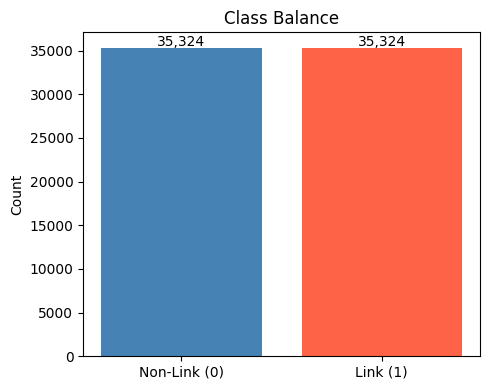

In [43]:
vc = df[TARGET_COLUMN].value_counts().sort_index()
print(vc)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Non-Link (0)", "Link (1)"], vc.values, color=["steelblue", "tomato"])
ax.set_ylabel("Count")
ax.set_title("Class Balance")
for i, v in enumerate(vc.values):
    ax.text(i, v + 200, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

The dataset is balanced: 35,324 existing edges (link=1) and 35,324 non-edges (link=0).

## 2. Feature Distributions by Class

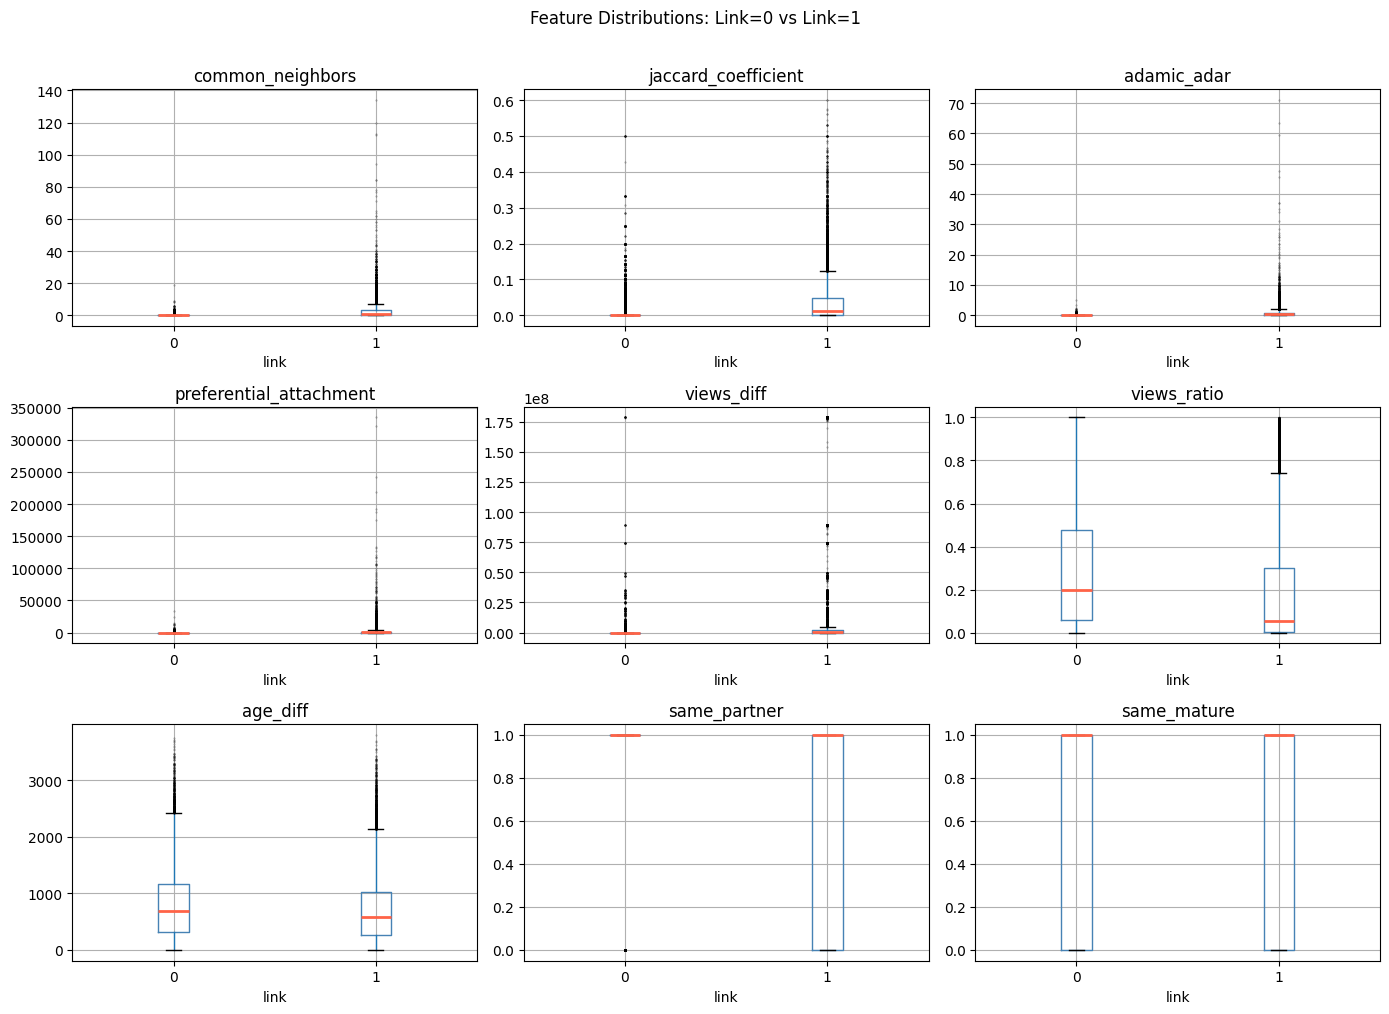

In [44]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]
    df.boxplot(column=col, by=TARGET_COLUMN, ax=ax,
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="tomato", linewidth=2),
               flierprops=dict(marker=".", markersize=1, alpha=0.3))
    ax.set_title(col)
    ax.set_xlabel("link")

plt.suptitle("Feature Distributions: Link=0 vs Link=1", y=1.01)
plt.tight_layout()
plt.show()

## 3. Correlation Heatmap

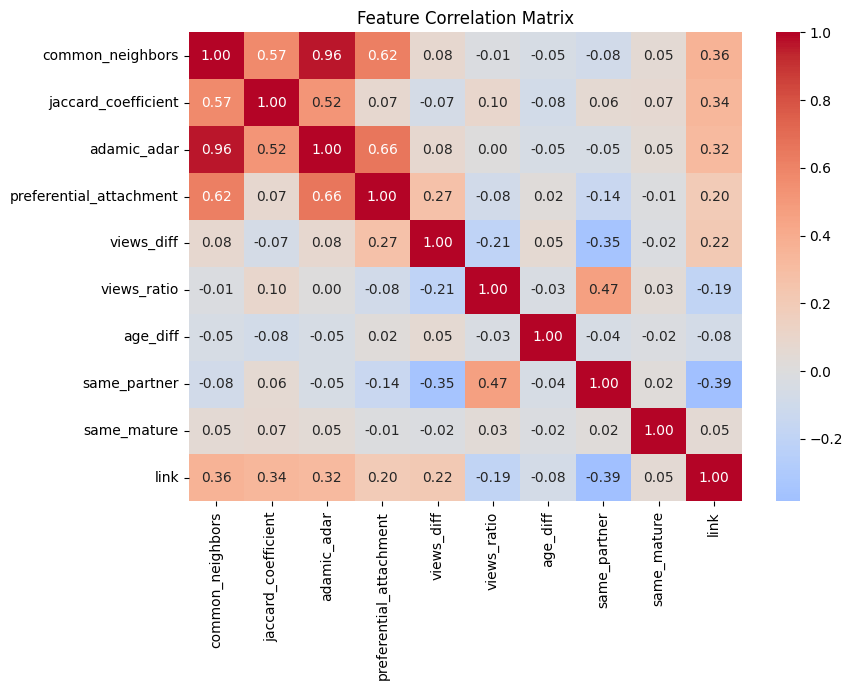

In [45]:
corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Train / Test Split

In [46]:
X = df[FEATURE_COLUMNS].values.astype(float)
y = df[TARGET_COLUMN].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Training set: {len(X_train):,}")
print(f"Test set:     {len(X_test):,}")

Training set: 56,518
Test set:     14,130


## 5. Cross-Validation (10-Fold)

In [47]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
])

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
cv_scores = {"AUC": [], "Accuracy": [], "Precision": [], "Recall": [], "F1": []}

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
    Xtr, Xval = X_train[tr_idx], X_train[val_idx]
    ytr, yval = y_train[tr_idx], y_train[val_idx]
    pipeline.fit(Xtr, ytr)
    y_pred = pipeline.predict(Xval)
    y_prob = pipeline.predict_proba(Xval)[:, 1]
    cv_scores["AUC"].append(roc_auc_score(yval, y_prob))
    cv_scores["Accuracy"].append(accuracy_score(yval, y_pred))
    cv_scores["Precision"].append(precision_score(yval, y_pred, zero_division=0))
    cv_scores["Recall"].append(recall_score(yval, y_pred))
    cv_scores["F1"].append(f1_score(yval, y_pred))
    print(f"Fold {fold+1}  Acc: {cv_scores['Accuracy'][-1]:.3f}  AUC: {cv_scores['AUC'][-1]:.3f}")

print()
print("Average CV Metrics:")
for name, scores in cv_scores.items():
    print(f"  {name:<12}: {np.mean(scores):.3f} (+/- {np.std(scores):.3f})")


Fold 1  Acc: 0.853  AUC: 0.917
Fold 2  Acc: 0.848  AUC: 0.914
Fold 3  Acc: 0.845  AUC: 0.904
Fold 4  Acc: 0.844  AUC: 0.903
Fold 5  Acc: 0.853  AUC: 0.913
Fold 6  Acc: 0.842  AUC: 0.908
Fold 7  Acc: 0.848  AUC: 0.910
Fold 8  Acc: 0.844  AUC: 0.908
Fold 9  Acc: 0.842  AUC: 0.905
Fold 10  Acc: 0.838  AUC: 0.900

Average CV Metrics:
  AUC         : 0.908 (+/- 0.005)
  Accuracy    : 0.846 (+/- 0.005)
  Precision   : 0.918 (+/- 0.006)
  Recall      : 0.759 (+/- 0.011)
  F1          : 0.831 (+/- 0.006)


## 6. Test Set Evaluation

In [48]:
pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)
y_prob_test = pipeline.predict_proba(X_test)[:, 1]

print(f"AUC:      {roc_auc_score(y_test, y_prob_test):.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.3f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Non-Link", "Link"]))

AUC:      0.910
Accuracy: 0.843

              precision    recall  f1-score   support

    Non-Link       0.79      0.93      0.86      7065
        Link       0.92      0.75      0.83      7065

    accuracy                           0.84     14130
   macro avg       0.85      0.84      0.84     14130
weighted avg       0.85      0.84      0.84     14130



## 7. Confusion Matrix & ROC Curve

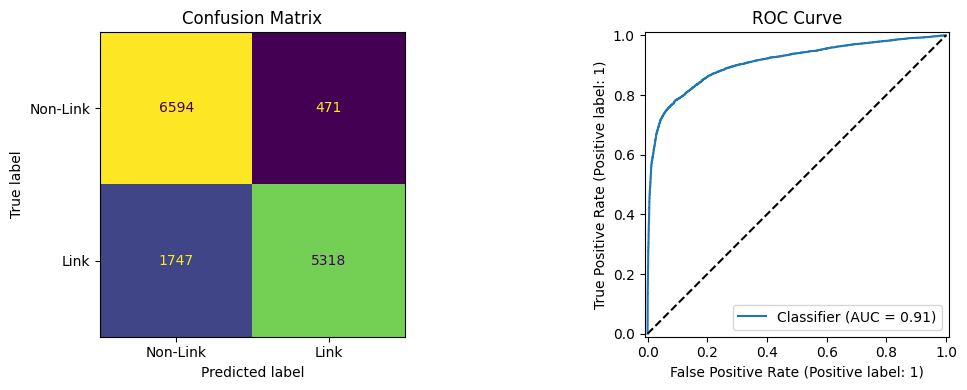

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_test),
    display_labels=["Non-Link", "Link"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob_test, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].plot([0,1],[0,1],"k--")

plt.tight_layout()
plt.show()

## 8. Model Coefficients

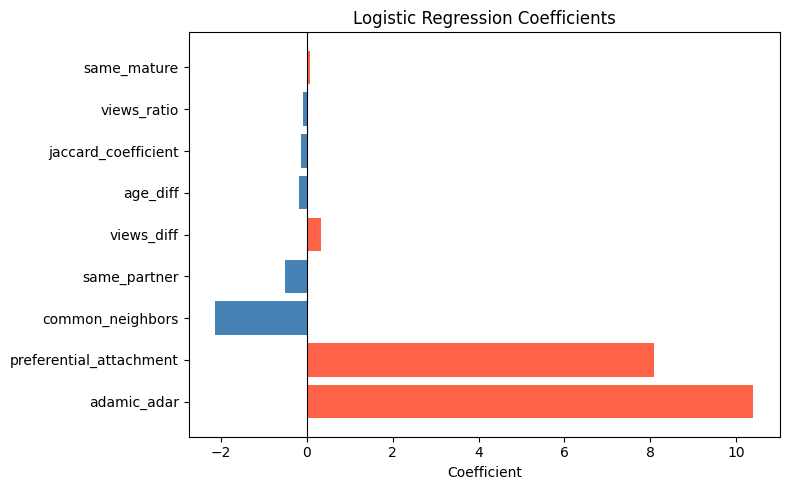

                feature  coefficient
            adamic_adar    10.400044
preferential_attachment     8.086998
       common_neighbors    -2.133532
           same_partner    -0.505409
             views_diff     0.318632
               age_diff    -0.191487
    jaccard_coefficient    -0.129917
            views_ratio    -0.081839
            same_mature     0.073617


In [50]:
feature_names = FEATURE_COLUMNS
coefs = pipeline.named_steps["lr"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["tomato" if c > 0 else "steelblue" for c in coef_df.coefficient]
ax.barh(coef_df.feature, coef_df.coefficient, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient")
ax.set_title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

## 9. Error Analysis

In [51]:
indices = np.arange(len(df))
idx_train, idx_test = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

df_test_meta = df.iloc[idx_test][["from", "to"] + FEATURE_COLUMNS].reset_index(drop=True)
df_results = df_test_meta.copy()
df_results["link"]        = y_test
df_results["prediction"]  = y_pred_test
df_results["probability"] = y_prob_test

fn = df_results[(df_results["link"] == 1) & (df_results["prediction"] == 0)]
fp = df_results[(df_results["link"] == 0) & (df_results["prediction"] == 1)]

print(f"False negatives: {len(fn)}")
print(f"False positives: {len(fp)}")
print(f"FN: AA=0 rate:   {(fn.adamic_adar == 0).mean()*100:.1f}%")
print(f"FN: PA median:   {fn.preferential_attachment.median():.0f}")

from datetime import datetime
import os

ts = datetime.now().strftime("%Y%m%d_%H%M")
out_dir = f"output/{ts}"
os.makedirs(out_dir, exist_ok=True)

fn.to_csv(f"{out_dir}/lr_full_bce_fn.csv", index=False)
fp.to_csv(f"{out_dir}/lr_full_bce_fp.csv", index=False)
print(f"Saved to {out_dir}/")


False negatives: 1747
False positives: 471
FN: AA=0 rate:   93.1%
FN: PA median:   88
Saved to output/20260524_2044/
